In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct
from scipy.signal import find_peaks as fp
from scipy.integrate import solve_ivp

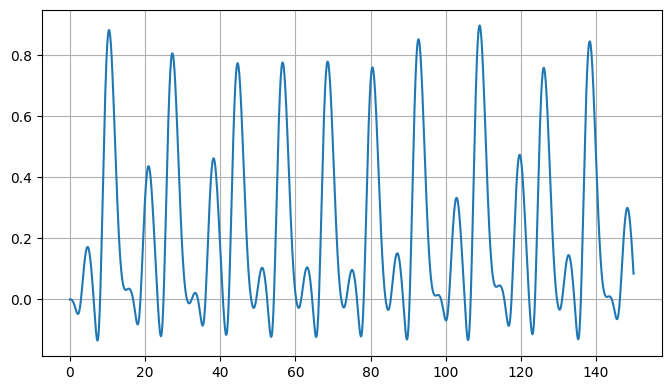

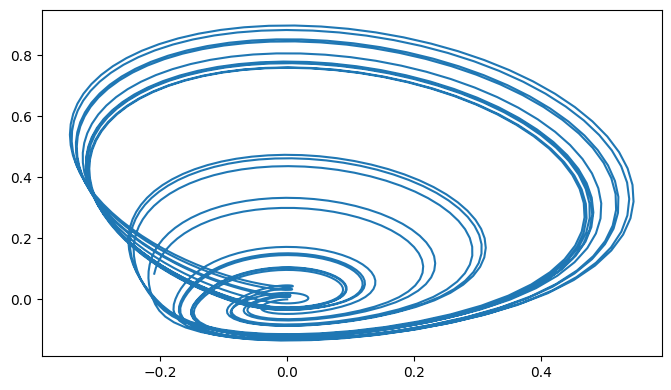

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

R = 0.047e6

# (R/R0) * V0
# R = 0.047M,   R0 = 0.148M,    V0 = 0.300V
constInput = (0.047e6)/(0.148e6 + 7.43e3) * 0.300

# numerical solution of ODE with a given ratio of (R/Rv)
def ivpODE(ratio):
    def thirdOrderODE(t, xt):
        x = xt[0]
        dx = xt[1]
        d2x = xt[2]
        d3x = -ratio*d2x - dx - 6.6729*min(x,0) - constInput
        return np.array([dx,d2x,d3x])
    return thirdOrderODE

# with a given ratio of (R/Rv) uses solve_ivp to get wave data for a chaotic system and returns voltage x()
def getSol(ratio):
    sln = solve_ivp(ivpODE(ratio),t_span=[0,150],y0=np.zeros(3),max_step=0.1)
    return sln.t,sln.y[0],sln.y[1]

t,x,dx = getSol(R/83e3)
fig = plt.figure(figsize=(8,4.5),dpi=100)
plt.plot(t,x)
plt.grid()
plt.show()

fig = plt.figure(figsize=(8,4.5),dpi=100)
plt.plot(dx,x)
plt.show()